**code des problèmes**

100%|██████████| 26.4M/26.4M [00:02<00:00, 11.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 177kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.20MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.7MB/s]


Utilisation du device: cuda

=== Expérience 1: Disparition du gradient (Vanishing Gradient) avec SGD ===


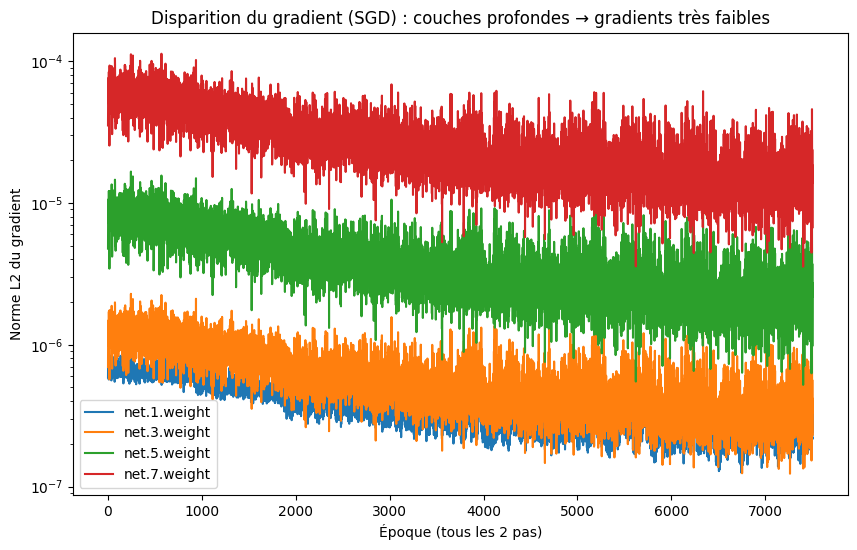

Observation: Les gradients des couches proches de l'entrée (ex: net.1.weight) sont beaucoup plus faibles que ceux des couches de sortie. Avec SGD, le phénomène est encore plus marqué qu'avec Adam.

=== Expérience 2: Surapprentissage (Overfitting) avec SGD ===


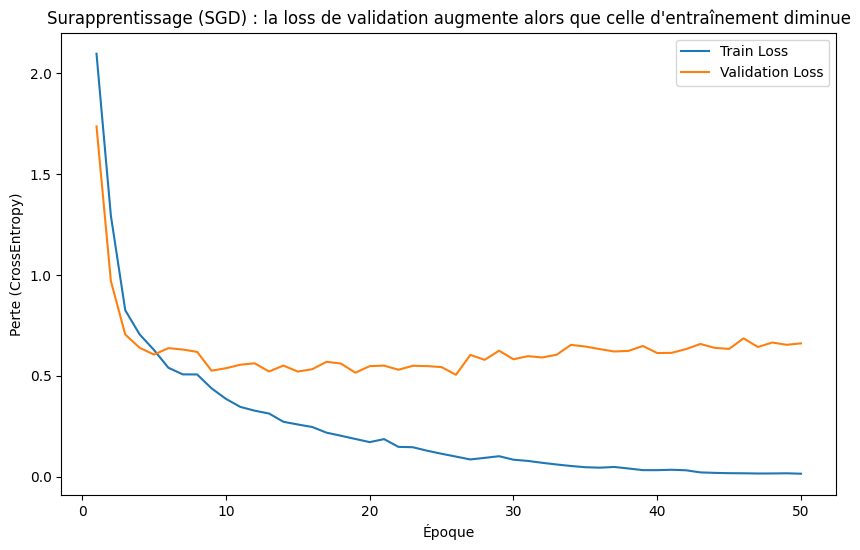

Observation: La loss de validation se dégrade après quelques époques, signe de surapprentissage. Le modèle mémorise les données d'entraînement mais ne généralise pas.

=== Expérience 3: Optimisation non convexe avec SGD ===


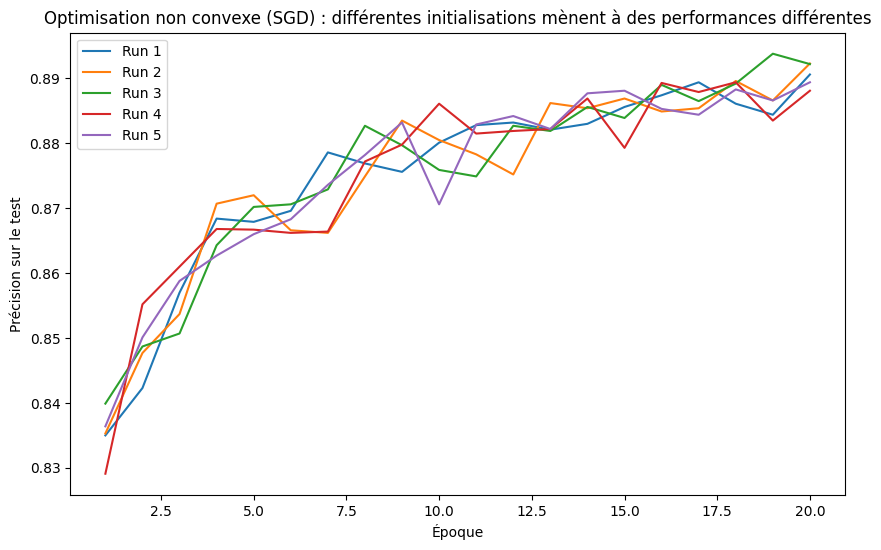

Précisions finales: [0.8906, 0.8923, 0.8922, 0.8881, 0.8894]
Observation: Les modèles atteignent des minima différents (souvent locaux) avec des écarts de performance notables. C'est dû à la non-convexité de la fonction de perte.

=== Expérience 4: Changement de distribution (Covariate Shift) ===
Entraînement sur données normales (sans bruit) pendant 15 époques...

Modèle sans BatchNorm :
  - Précision sur test original : 0.8841
  - Précision sur test bruité   : 0.8714
Modèle avec BatchNorm :
  - Précision sur test original : 0.8900
  - Précision sur test bruité   : 0.8646


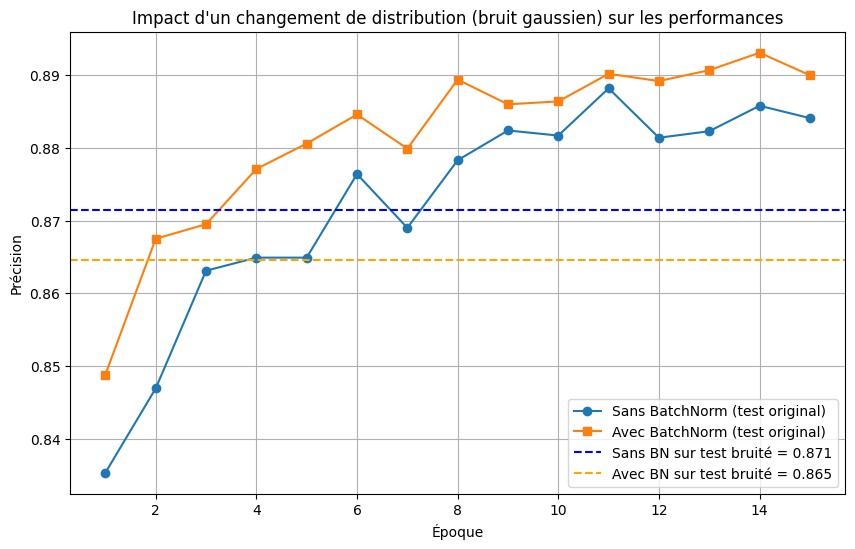


Observation: Le bruit ajouté modifie la distribution des entrées (covariate shift). Le modèle sans BatchNorm voit ses performances chuter beaucoup plus que celui avec BatchNorm. BatchNorm réduit l'effet du covariate shift en normalisant les activations internes.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
import copy
import random

# Pour la reproductibilité partielle
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# 1. Préparation du dataset Fashion-MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalisation entre -1 et 1
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Pour certains tests (surapprentissage), on utilise un petit sous-ensemble
small_train_dataset = Subset(train_dataset, indices=list(range(1000)))
small_val_dataset = Subset(test_dataset, indices=list(range(200)))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
small_train_loader = DataLoader(small_train_dataset, batch_size=64, shuffle=True)
small_val_loader = DataLoader(small_val_dataset, batch_size=64, shuffle=False)

# 2. Définition des modèles

# a) Réseau profond avec sigmoïde -> disparition du gradient
class VanishingGradientNet(nn.Module):
    def __init__(self, n_layers=8, hidden_size=256):
        super().__init__()
        layers = []
        layers.append(nn.Flatten())
        layers.append(nn.Linear(28*28, hidden_size))
        layers.append(nn.Sigmoid())
        for _ in range(n_layers - 1):
            layers.append(nn.Linear(hidden_size, hidden_size))
            layers.append(nn.Sigmoid())
        layers.append(nn.Linear(hidden_size, 10))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# b) Réseau très large (surapprentissage)
class OverfittingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        return self.fc3(x)

# c) Réseau de référence SANS BatchNorm
class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        return self.fc3(x)

# d) Réseau AVEC BatchNorm (pour comparaison dans l'expérience covariate shift)
class BaselineNetWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.bn1 = nn.BatchNorm1d(256)
        self.fc2 = nn.Linear(256, 128)
        self.bn2 = nn.BatchNorm1d(128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = self.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        return self.fc3(x)

# 3. Utilitaires : calcul des normes des gradients par couche
def compute_gradient_norms(model):
    norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            norm = param.grad.norm(2).item()
            norms.append((name, norm))
    return norms

def plot_gradient_norms(norms_per_epoch, title="Évolution des normes de gradient"):
    epochs = range(1, len(norms_per_epoch)+1)
    layers = list(norms_per_epoch[0].keys())
    for layer in layers:
        values = [epoch_norms[layer] for epoch_norms in norms_per_epoch if layer in epoch_norms]
        if values:
            plt.plot(epochs[:len(values)], values, label=layer)
    plt.xlabel('Époque')
    plt.ylabel('Norme L2 du gradient')
    plt.title(title)
    plt.legend()
    plt.yscale('log')
    plt.show()

# 4. Fonction d'entraînement et d'évaluation avec SGD
def train_and_evaluate(model, train_loader, val_loader, epochs=20, lr=0.01, momentum=0.9, device='cpu',
                       record_gradients=False, verbose=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

    train_losses = []
    val_losses = []
    val_accuracies = []
    gradient_norms_history = [] if record_gradients else None

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()

            if record_gradients and epoch % 2 == 0:
                norms = compute_gradient_norms(model)
                norms_dict = {name: norm for name, norm in norms}
                gradient_norms_history.append(norms_dict)

            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Évaluation
        model.eval()
        val_loss = 0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total
        val_losses.append(avg_val_loss)
        val_accuracies.append(val_acc)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, val_accuracies, gradient_norms_history

# 5. Expériences existantes

def experiment_vanishing_gradient(device='cpu'):
    print("\n=== Expérience 1: Disparition du gradient (Vanishing Gradient) avec SGD ===")
    model = VanishingGradientNet(n_layers=8, hidden_size=256)
    _, _, _, grad_norms = train_and_evaluate(model, train_loader, test_loader, epochs=15,
                                             lr=0.01, device=device, record_gradients=True, verbose=False)
    layer_names = [name for name, _ in grad_norms[0].items() if 'weight' in name]
    norms_per_layer = {name: [] for name in layer_names}
    for epoch_norms in grad_norms:
        for name in layer_names:
            norms_per_layer[name].append(epoch_norms.get(name, 0))
    plt.figure(figsize=(10,6))
    for name, norms in norms_per_layer.items():
        if 'net.1.weight' in name or 'net.3.weight' in name or 'net.5.weight' in name or 'net.7.weight' in name:
            plt.plot(range(1, len(norms)+1), norms, label=name)
    plt.xlabel('Époque (tous les 2 pas)')
    plt.ylabel('Norme L2 du gradient')
    plt.title("Disparition du gradient (SGD) : couches profondes → gradients très faibles")
    plt.legend()
    plt.yscale('log')
    plt.show()
    print("Observation: Les gradients des couches proches de l'entrée (ex: net.1.weight) sont beaucoup plus faibles que ceux des couches de sortie. Avec SGD, le phénomène est encore plus marqué qu'avec Adam.")

def experiment_overfitting(device='cpu'):
    print("\n=== Expérience 2: Surapprentissage (Overfitting) avec SGD ===")
    model = OverfittingNet()
    train_losses, val_losses, val_accs, _ = train_and_evaluate(model, small_train_loader, small_val_loader,
                                                              epochs=50, lr=0.01, device=device, verbose=False)
    plt.figure(figsize=(10,6))
    plt.plot(range(1,51), train_losses, label='Train Loss')
    plt.plot(range(1,51), val_losses, label='Validation Loss')
    plt.xlabel('Époque')
    plt.ylabel('Perte (CrossEntropy)')
    plt.title("Surapprentissage (SGD) : la loss de validation augmente alors que celle d'entraînement diminue")
    plt.legend()
    plt.show()
    print("Observation: La loss de validation se dégrade après quelques époques, signe de surapprentissage. Le modèle mémorise les données d'entraînement mais ne généralise pas.")

def experiment_nonconvex_optimization(device='cpu', n_runs=5):
    print("\n=== Expérience 3: Optimisation non convexe avec SGD ===")
    all_val_accs = []
    for run in range(n_runs):
        set_seed(run)
        model = BaselineNet()   # sans BatchNorm
        _, _, val_accs, _ = train_and_evaluate(model, train_loader, test_loader, epochs=20,
                                              lr=0.01, device=device, verbose=False)
        all_val_accs.append(val_accs)
    plt.figure(figsize=(10,6))
    for i, accs in enumerate(all_val_accs):
        plt.plot(range(1,21), accs, label=f'Run {i+1}')
    plt.xlabel('Époque')
    plt.ylabel('Précision sur le test')
    plt.title("Optimisation non convexe (SGD) : différentes initialisations mènent à des performances différentes")
    plt.legend()
    plt.show()
    final_accs = [accs[-1] for accs in all_val_accs]
    print(f"Précisions finales: {final_accs}")
    print("Observation: Les modèles atteignent des minima différents (souvent locaux) avec des écarts de performance notables. C'est dû à la non-convexité de la fonction de perte.")

# Nouvelle expérience : Covariate Shift
def experiment_covariate_shift(device='cpu'):
    print("\n=== Expérience 4: Changement de distribution (Covariate Shift) ===")
    # Création d'un jeu de test modifié : ajout de bruit gaussien pour simuler un covariate shift
    def add_gaussian_noise(tensor, mean=0.0, std=0.3):
        noise = torch.randn_like(tensor) * std + mean
        return tensor + noise

    # Préparer le test set original
    test_dataset_original = test_dataset
    # Créer un test set bruité
    test_images_noisy = []
    test_labels = []
    for i in range(len(test_dataset_original)):
        img, label = test_dataset_original[i]
        noisy_img = add_gaussian_noise(img, std=0.3)
        # Recadrer les valeurs après bruit pour rester dans [-1,1] (optionnel)
        noisy_img = torch.clamp(noisy_img, -1, 1)
        test_images_noisy.append(noisy_img)
        test_labels.append(label)
    test_dataset_noisy = TensorDataset(torch.stack(test_images_noisy), torch.tensor(test_labels))
    test_loader_noisy = DataLoader(test_dataset_noisy, batch_size=64, shuffle=False)

    # Modèles: BaselineNet (sans BN) et BaselineNetWithBN (avec BN)
    model_no_bn = BaselineNet()
    model_with_bn = BaselineNetWithBN()

    print("Entraînement sur données normales (sans bruit) pendant 15 époques...")
    # Entraînement du modèle sans BN
    _, _, val_accs_no_bn, _ = train_and_evaluate(model_no_bn, train_loader, test_loader,
                                                 epochs=15, lr=0.01, device=device, verbose=False)
    # Entraînement du modèle avec BN
    _, _, val_accs_with_bn, _ = train_and_evaluate(model_with_bn, train_loader, test_loader,
                                                   epochs=15, lr=0.01, device=device, verbose=False)

    # Évaluation sur le test set bruité
    def evaluate_on_loader(model, loader, device):
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        return correct / total

    acc_no_bn_original = val_accs_no_bn[-1]  # précision finale sur test original (dernière époque)
    acc_no_bn_noisy = evaluate_on_loader(model_no_bn, test_loader_noisy, device)
    acc_with_bn_original = val_accs_with_bn[-1]
    acc_with_bn_noisy = evaluate_on_loader(model_with_bn, test_loader_noisy, device)

    print(f"\nModèle sans BatchNorm :")
    print(f"  - Précision sur test original : {acc_no_bn_original:.4f}")
    print(f"  - Précision sur test bruité   : {acc_no_bn_noisy:.4f}")
    print(f"Modèle avec BatchNorm :")
    print(f"  - Précision sur test original : {acc_with_bn_original:.4f}")
    print(f"  - Précision sur test bruité   : {acc_with_bn_noisy:.4f}")

    # Visualisation de l'évolution de la précision sur le test original (pour info)
    plt.figure(figsize=(10,6))
    plt.plot(range(1,16), val_accs_no_bn, label='Sans BatchNorm (test original)', marker='o')
    plt.plot(range(1,16), val_accs_with_bn, label='Avec BatchNorm (test original)', marker='s')
    plt.axhline(y=acc_no_bn_noisy, color='blue', linestyle='--', label=f'Sans BN sur test bruité = {acc_no_bn_noisy:.3f}')
    plt.axhline(y=acc_with_bn_noisy, color='orange', linestyle='--', label=f'Avec BN sur test bruité = {acc_with_bn_noisy:.3f}')
    plt.xlabel('Époque')
    plt.ylabel('Précision')
    plt.title("Impact d'un changement de distribution (bruit gaussien) sur les performances")
    plt.legend()
    plt.grid(True)
    plt.show()

    print("\nObservation: Le bruit ajouté modifie la distribution des entrées (covariate shift). Le modèle sans BatchNorm voit ses performances chuter beaucoup plus que celui avec BatchNorm. BatchNorm réduit l'effet du covariate shift en normalisant les activations internes.")

# 6. Exécution principale
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Utilisation du device: {device}")

    # Lancer les trois expériences existantes
    experiment_vanishing_gradient(device)
    experiment_overfitting(device)
    experiment_nonconvex_optimization(device)

    # Lancer la nouvelle expérience sur le covariate shift
    experiment_covariate_shift(device)

**code optimiser**

Found existing installation: sympy 1.13.3
Uninstalling sympy-1.13.3:
  Successfully uninstalled sympy-1.13.3
  Using cached sympy-1.13.3-py3-none-any.whl.metadata (12 kB)
Using cached sympy-1.13.3-py3-none-any.whl (6.2 MB)
Utilisation du device: cpu

=== Expérience 1: Disparition du Gradient et Solutions (2.2) ===
--- Problème: Réseau profond avec Sigmoïde ---
--- Solution 2.2.1: Initialisation de Xavier ---
--- Solution 2.2.2: Batch Normalization ---
--- Solution 2.2.3: Connexions Résiduelles ---


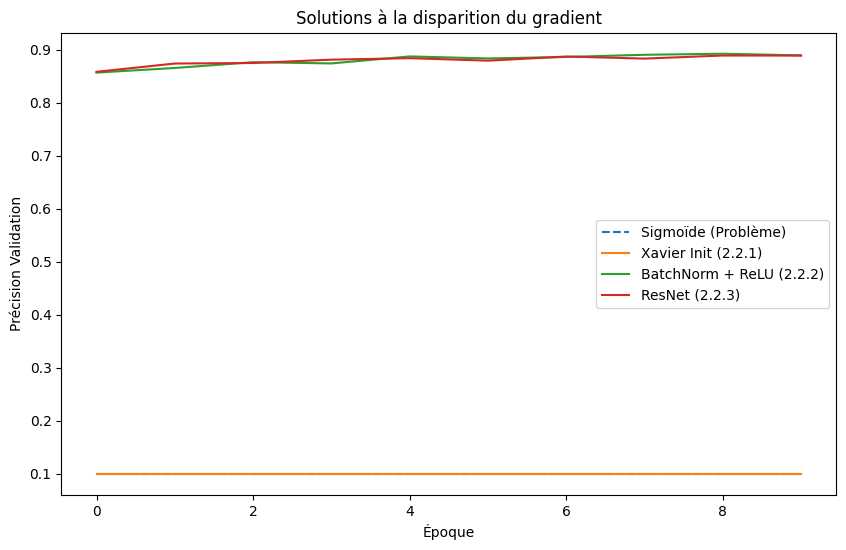


=== Expérience 2: Surapprentissage et Solutions (2.1) ===
--- Problème: Réseau large sur petit dataset ---
--- Solution 2.1.2: Régularisation L2 (Ridge) ---
--- Solution 2.1.3: Régularisation L1 (Lasso) ---
--- Solution 2.1.4: Dropout ---


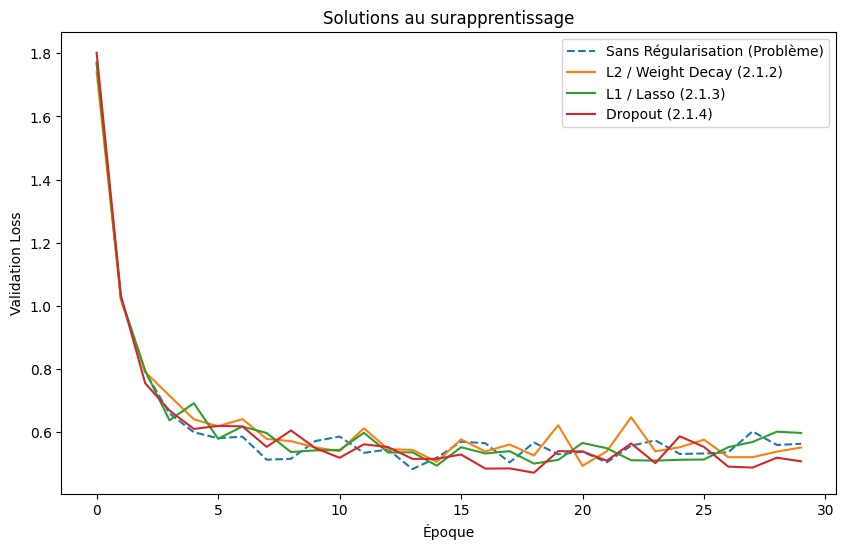


=== Expérience 3: Optimisation Non Convexe et Solutions (2.3) ===
--- Problème: SGD avec différentes initialisations ---
SGD Précisions finales: ['0.8799', '0.8787', '0.8798'], Variance: 0.000000
--- Solution 2.3.2: Optimiseur Adam ---
Adam Précisions finales: ['0.8801', '0.8777', '0.8804'], Variance: 0.000001
--- Solution 2.3.3: LBFGS (Méthode de Newton tronquée) ---
LBFGS Précisions finales (sur 500 imgs): ['0.7650', '0.8150', '0.8050'], Variance: 0.000467
Observation: Adam réduit la variance et converge mieux que SGD. LBFGS (quasi-Newton) est très stable mais nécessite beaucoup de mémoire.


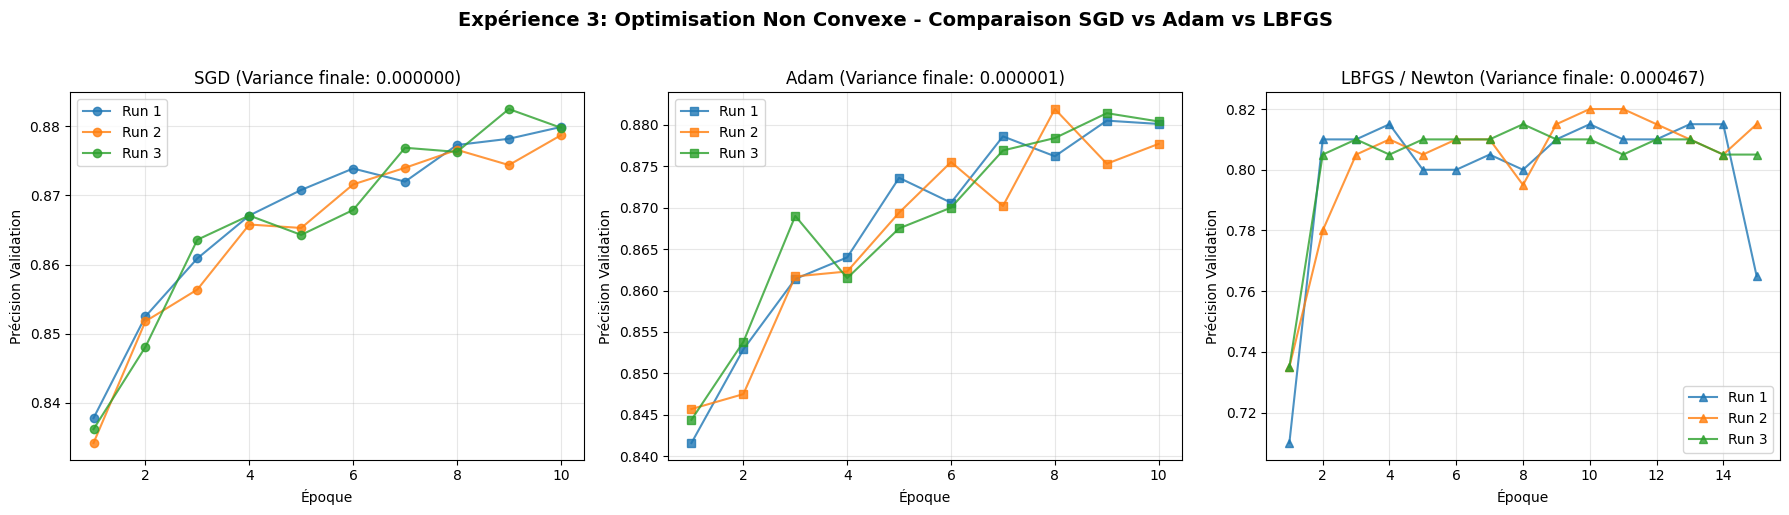

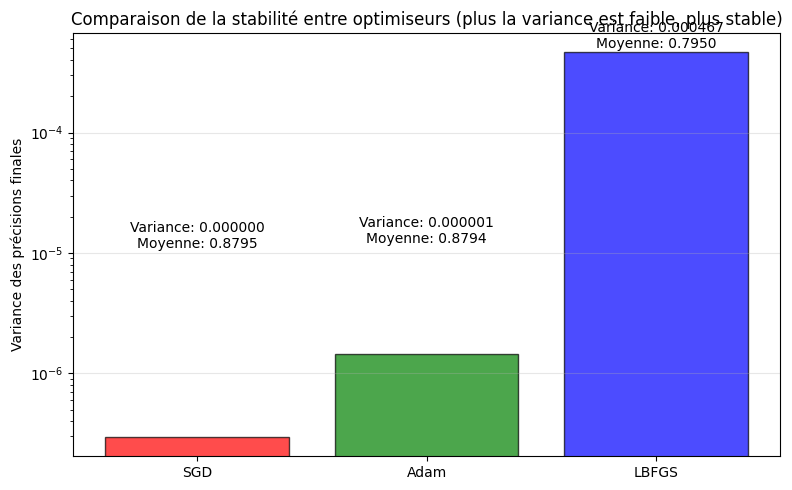


=== Expérience 4: Covariate Shift et Solution (2.4) ===
--- Problème: Baisse de performance sur distribution décalée ---
Précision sans solution sur test bruité: 0.8651
--- Solution 2.4.2: Rééchantillonnage par Importance (Discriminateur) ---
Précision avec Importance Weighting sur test bruité: 0.8649


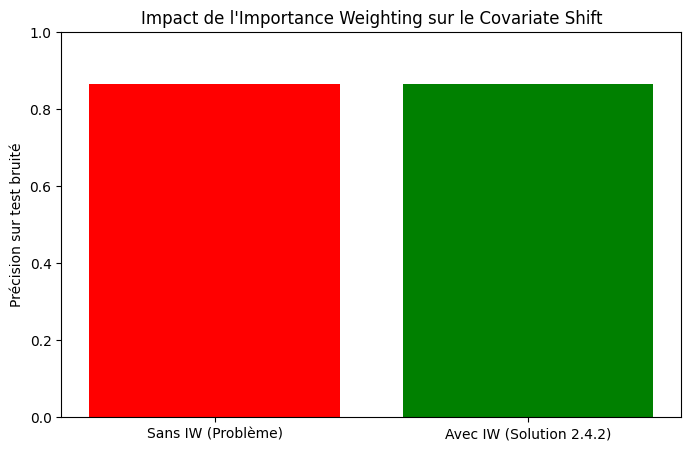

In [ ]:
# Désinstaller la version incompatible
!pip uninstall sympy -y

# Installer la version compatible avec PyTorch 2.11.0
!pip install sympy==1.13.3



import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import random

# Pour la reproductibilité
def set_seed(seed):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

# ==============================================================================
# 1. Préparation du dataset Fashion-MNIST
# ==============================================================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

small_train_dataset = Subset(train_dataset, indices=list(range(1000)))
small_val_dataset = Subset(test_dataset, indices=list(range(200)))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
small_train_loader = DataLoader(small_train_dataset, batch_size=64, shuffle=True)
small_val_loader = DataLoader(small_val_dataset, batch_size=64, shuffle=False)

# ==============================================================================
# 2. Définition des Modèles
# ==============================================================================

class VanishingGradientNet(nn.Module):
    def __init__(self, n_layers=8, hidden_size=256, use_xavier=False):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28*28, hidden_size), nn.Sigmoid()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_size, hidden_size), nn.Sigmoid()])
        layers.append(nn.Linear(hidden_size, 10))
        self.net = nn.Sequential(*layers)
        if use_xavier:
            for m in self.modules():
                if isinstance(m, nn.Linear):
                    nn.init.xavier_uniform_(m.weight)
    def forward(self, x): return self.net(x)

class DeepNetWithBN(nn.Module):
    def __init__(self, n_layers=8, hidden_size=256):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(28*28, hidden_size), nn.BatchNorm1d(hidden_size), nn.ReLU()]
        for _ in range(n_layers - 1):
            layers.extend([nn.Linear(hidden_size, hidden_size), nn.BatchNorm1d(hidden_size), nn.ReLU()])
        layers.append(nn.Linear(hidden_size, 10))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, out_features)
        self.bn1 = nn.BatchNorm1d(out_features)
        self.fc2 = nn.Linear(out_features, out_features)
        self.bn2 = nn.BatchNorm1d(out_features)
        self.shortcut = nn.Sequential()
        if in_features != out_features:
            self.shortcut = nn.Sequential(
                nn.Linear(in_features, out_features), nn.BatchNorm1d(out_features)
            )
    def forward(self, x):
        out = F.relu(self.bn1(self.fc1(x)))
        out = self.bn2(self.fc2(out))
        out += self.shortcut(x)
        return F.relu(out)

class ResidualNet(nn.Module):
    def __init__(self, n_blocks=4, hidden_size=256):
        super().__init__()
        self.flatten = nn.Flatten()
        self.initial = nn.Sequential(nn.Linear(28*28, hidden_size), nn.BatchNorm1d(hidden_size), nn.ReLU())
        self.blocks = nn.Sequential(*[ResidualBlock(hidden_size, hidden_size) for _ in range(n_blocks)])
        self.fc_out = nn.Linear(hidden_size, 10)
    def forward(self, x):
        x = self.flatten(x)
        x = self.initial(x)
        x = self.blocks(x)
        return self.fc_out(x)

class OverfittingNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(28*28, 1024), nn.ReLU(),
            nn.Linear(1024, 1024), nn.ReLU(), nn.Linear(1024, 10)
        )
    def forward(self, x): return self.net(x)

class OverfittingNetWithDropout(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 1024)
        self.fc2 = nn.Linear(1024, 1024)
        self.fc3 = nn.Linear(1024, 10)
        self.dropout = nn.Dropout(0.5)
    def forward(self, x):
        x = self.flatten(x)
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        return self.fc3(x)

class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(), nn.Linear(28*28, 256), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.2), nn.Linear(128, 10)
        )
    def forward(self, x): return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(28*28, 128), nn.ReLU(), nn.Linear(128, 1))
    def forward(self, x): return self.net(x)

# ==============================================================================
# 3. Utilitaires d'Entraînement
# ==============================================================================
def train_and_evaluate(model, train_loader, val_loader, epochs=20, lr=0.01, momentum=0.9,
                       weight_decay=0.0, l1_penalty=0.0, optimizer_type='sgd', device='cpu', verbose=True):
    model.to(device)
    criterion = nn.CrossEntropyLoss(reduction='none')

    if optimizer_type == 'sgd':
        optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    elif optimizer_type == 'adam':
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_type == 'lbfgs':
        optimizer = optim.LBFGS(model.parameters(), lr=lr, max_iter=20)

    train_losses, val_losses, val_accuracies = [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            if len(batch) == 3:
                images, labels, weights = batch
                weights = weights.to(device)
            else:
                images, labels = batch
                weights = None

            images, labels = images.to(device), labels.to(device)

            if optimizer_type == 'lbfgs':
                def closure():
                    optimizer.zero_grad()
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                    loss = (loss * weights).mean() if weights is not None else loss.mean()
                    if l1_penalty > 0:
                        l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
                        loss += l1_penalty * l1_reg
                    loss.backward()
                    return loss
                loss_val = optimizer.step(closure)
                total_loss += loss_val if loss_val is not None else closure().item()
            else:
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss = (loss * weights).mean() if weights is not None else loss.mean()
                if l1_penalty > 0:
                    l1_reg = sum(torch.norm(p, 1) for p in model.parameters())
                    loss += l1_penalty * l1_reg
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        model.eval()
        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                val_loss += criterion(outputs, labels).mean().item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_losses.append(val_loss / len(val_loader))
        val_accuracies.append(correct / total)

        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")

    return train_losses, val_losses, val_accuracies

# ==============================================================================
# 4. Expériences
# ==============================================================================

def experiment_vanishing_gradient_and_solutions(device='cpu'):
    print("\n=== Expérience 1: Disparition du Gradient et Solutions (2.2) ===")

    print("--- Problème: Réseau profond avec Sigmoïde ---")
    model_base = VanishingGradientNet(n_layers=8, hidden_size=256, use_xavier=False)
    _, _, accs_base = train_and_evaluate(model_base, train_loader, test_loader, epochs=10, device=device, verbose=False)

    print("--- Solution 2.2.1: Initialisation de Xavier ---")
    model_xavier = VanishingGradientNet(n_layers=8, hidden_size=256, use_xavier=True)
    _, _, accs_xavier = train_and_evaluate(model_xavier, train_loader, test_loader, epochs=10, device=device, verbose=False)

    print("--- Solution 2.2.2: Batch Normalization ---")
    model_bn = DeepNetWithBN(n_layers=8, hidden_size=256)
    _, _, accs_bn = train_and_evaluate(model_bn, train_loader, test_loader, epochs=10, device=device, verbose=False)

    print("--- Solution 2.2.3: Connexions Résiduelles ---")
    model_res = ResidualNet(n_blocks=4, hidden_size=256)
    _, _, accs_res = train_and_evaluate(model_res, train_loader, test_loader, epochs=10, device=device, verbose=False)

    plt.figure(figsize=(10,6))
    plt.plot(accs_base, label='Sigmoïde (Problème)', linestyle='--')
    plt.plot(accs_xavier, label='Xavier Init (2.2.1)')
    plt.plot(accs_bn, label='BatchNorm + ReLU (2.2.2)')
    plt.plot(accs_res, label='ResNet (2.2.3)')
    plt.xlabel('Époque'); plt.ylabel('Précision Validation')
    plt.title('Solutions à la disparition du gradient'); plt.legend(); plt.show()

def experiment_overfitting_and_solutions(device='cpu'):
    print("\n=== Expérience 2: Surapprentissage et Solutions (2.1) ===")

    print("--- Problème: Réseau large sur petit dataset ---")
    model_base = OverfittingNet()
    _, val_base, _ = train_and_evaluate(model_base, small_train_loader, small_val_loader, epochs=30, device=device, verbose=False)

    print("--- Solution 2.1.2: Régularisation L2 (Ridge) ---")
    model_l2 = OverfittingNet()
    _, val_l2, _ = train_and_evaluate(model_l2, small_train_loader, small_val_loader, epochs=30, weight_decay=1e-2, device=device, verbose=False)

    print("--- Solution 2.1.3: Régularisation L1 (Lasso) ---")
    model_l1 = OverfittingNet()
    _, val_l1, _ = train_and_evaluate(model_l1, small_train_loader, small_val_loader, epochs=30, l1_penalty=1e-4, device=device, verbose=False)

    print("--- Solution 2.1.4: Dropout ---")
    model_drop = OverfittingNetWithDropout()
    _, val_drop, _ = train_and_evaluate(model_drop, small_train_loader, small_val_loader, epochs=30, device=device, verbose=False)

    plt.figure(figsize=(10,6))
    plt.plot(val_base, label='Sans Régularisation (Problème)', linestyle='--')
    plt.plot(val_l2, label='L2 / Weight Decay (2.1.2)')
    plt.plot(val_l1, label='L1 / Lasso (2.1.3)')
    plt.plot(val_drop, label='Dropout (2.1.4)')
    plt.xlabel('Époque'); plt.ylabel('Validation Loss')
    plt.title('Solutions au surapprentissage'); plt.legend(); plt.show()

def experiment_nonconvex_and_solutions(device='cpu', n_runs=3):
    print("\n=== Expérience 3: Optimisation Non Convexe et Solutions (2.3) ===")

    print("--- Problème: SGD avec différentes initialisations ---")
    accs_sgd = []
    curves_sgd = []
    for run in range(n_runs):
        set_seed(run)
        model = BaselineNet()
        _, _, val_accs = train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=0.01, device=device, verbose=False)
        accs_sgd.append(val_accs[-1])
        curves_sgd.append(val_accs)
    print(f"SGD Précisions finales: {[f'{a:.4f}' for a in accs_sgd]}, Variance: {np.var(accs_sgd):.6f}")

    print("--- Solution 2.3.2: Optimiseur Adam ---")
    accs_adam = []
    curves_adam = []
    for run in range(n_runs):
        set_seed(run)
        model = BaselineNet()
        _, _, val_accs = train_and_evaluate(model, train_loader, test_loader, epochs=10, lr=0.001, optimizer_type='adam', device=device, verbose=False)
        accs_adam.append(val_accs[-1])
        curves_adam.append(val_accs)
    print(f"Adam Précisions finales: {[f'{a:.4f}' for a in accs_adam]}, Variance: {np.var(accs_adam):.6f}")

    print("--- Solution 2.3.3: LBFGS (Méthode de Newton tronquée) ---")
    tiny_train = DataLoader(Subset(train_dataset, range(500)), batch_size=500, shuffle=True)
    tiny_val = DataLoader(Subset(test_dataset, range(200)), batch_size=200, shuffle=False)
    accs_lbfgs = []
    curves_lbfgs = []
    for run in range(n_runs):
        set_seed(run)
        model = BaselineNet()
        _, _, val_accs = train_and_evaluate(model, tiny_train, tiny_val, epochs=15, lr=1.0, optimizer_type='lbfgs', device=device, verbose=False)
        accs_lbfgs.append(val_accs[-1])
        curves_lbfgs.append(val_accs)
    print(f"LBFGS Précisions finales (sur 500 imgs): {[f'{a:.4f}' for a in accs_lbfgs]}, Variance: {np.var(accs_lbfgs):.6f}")

    print("Observation: Adam réduit la variance et converge mieux que SGD. LBFGS (quasi-Newton) est très stable mais nécessite beaucoup de mémoire.")

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for i, curve in enumerate(curves_sgd):
        axes[0].plot(range(1, len(curve)+1), curve, marker='o', label=f'Run {i+1}', alpha=0.8)
    axes[0].set_title(f'SGD (Variance finale: {np.var(accs_sgd):.6f})')
    axes[0].set_xlabel('Époque'); axes[0].set_ylabel('Précision Validation')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    for i, curve in enumerate(curves_adam):
        axes[1].plot(range(1, len(curve)+1), curve, marker='s', label=f'Run {i+1}', alpha=0.8)
    axes[1].set_title(f'Adam (Variance finale: {np.var(accs_adam):.6f})')
    axes[1].set_xlabel('Époque'); axes[1].set_ylabel('Précision Validation')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    for i, curve in enumerate(curves_lbfgs):
        axes[2].plot(range(1, len(curve)+1), curve, marker='^', label=f'Run {i+1}', alpha=0.8)
    axes[2].set_title(f'LBFGS / Newton (Variance finale: {np.var(accs_lbfgs):.6f})')
    axes[2].set_xlabel('Époque'); axes[2].set_ylabel('Précision Validation')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.suptitle('Expérience 3: Optimisation Non Convexe - Comparaison SGD vs Adam vs LBFGS',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 5))
    optimizers = ['SGD', 'Adam', 'LBFGS']
    variances = [np.var(accs_sgd), np.var(accs_adam), np.var(accs_lbfgs)]
    means = [np.mean(accs_sgd), np.mean(accs_adam), np.mean(accs_lbfgs)]

    bars = plt.bar(optimizers, variances, color=['red', 'green', 'blue'], alpha=0.7, edgecolor='black')
    for bar, mean, var in zip(bars, means, variances):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.00001,
                 f'Variance: {var:.6f}\nMoyenne: {mean:.4f}',
                 ha='center', va='bottom', fontsize=10)

    plt.ylabel('Variance des précisions finales')
    plt.title('Comparaison de la stabilité entre optimiseurs (plus la variance est faible, plus stable)')
    plt.yscale('log')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

# ==============================================================================
# CORRECTION ICI : Expérience 4 - Covariate Shift
# ==============================================================================
def experiment_covariate_shift_and_solutions(device='cpu'):
    print("\n=== Expérience 4: Covariate Shift et Solution (2.4) ===")

    def add_gaussian_noise(tensor, std=0.3):
        return torch.clamp(tensor + torch.randn_like(tensor) * std, -1, 1)

    # Créer le test set bruité - CORRECTION: extraire correctement les images et labels
    test_images_noisy = []
    test_labels_list = []
    for img, label in test_dataset:
        noisy_img = add_gaussian_noise(img)
        test_images_noisy.append(noisy_img)
        test_labels_list.append(label)

    # Convertir en tenseurs avant de créer TensorDataset
    test_images_stacked = torch.stack(test_images_noisy)
    test_labels_tensor = torch.tensor(test_labels_list)

    test_dataset_noisy = TensorDataset(test_images_stacked, test_labels_tensor)
    test_loader_noisy = DataLoader(test_dataset_noisy, batch_size=64, shuffle=False)

    print("--- Problème: Baisse de performance sur distribution décalée ---")
    model_base = BaselineNet()
    train_and_evaluate(model_base, train_loader, test_loader, epochs=10, device=device, verbose=False)
    model_base.eval()
    acc_base_noisy = sum((torch.max(model_base(x.to(device)), 1)[1] == y.to(device)).sum().item() for x, y in test_loader_noisy) / len(test_dataset_noisy)
    print(f"Précision sans solution sur test bruité: {acc_base_noisy:.4f}")

    print("--- Solution 2.4.2: Rééchantillonnage par Importance (Discriminateur) ---")
    disc = Discriminator().to(device)
    disc_opt = optim.Adam(disc.parameters(), lr=0.001)
    disc_crit = nn.BCEWithLogitsLoss()

    sub_size = 2000
    train_sub = DataLoader(Subset(train_dataset, range(sub_size)), batch_size=64, shuffle=True)
    test_sub = DataLoader(Subset(test_dataset_noisy, range(sub_size)), batch_size=64, shuffle=True)

    for epoch in range(3):
        disc.train()
        for (x_tr, _), (x_te, _) in zip(train_sub, test_sub):
            x_tr, x_te = x_tr.to(device), x_te.to(device)
            disc_opt.zero_grad()
            loss = (disc_crit(disc(x_tr), torch.zeros(x_tr.size(0), 1).to(device)) +
                    disc_crit(disc(x_te), torch.ones(x_te.size(0), 1).to(device))) / 2
            loss.backward()
            disc_opt.step()

    disc.eval()
    weights = []
    with torch.no_grad():
        for x, _ in DataLoader(train_dataset, batch_size=256):
            probs = torch.sigmoid(disc(x.to(device)))
            w = probs / (1 - probs + 1e-6)
            w = w / w.mean()
            weights.append(w.cpu())
    weights = torch.cat(weights)

    class WeightedDataset(TensorDataset):
        def __len__(self): return len(self.tensors[0])
        def __getitem__(self, idx):
            x = self.tensors[0][idx]
            y = self.tensors[1][idx]
            w = self.tensors[2][idx]
            return x, y, w

    # Convertir le dataset d'entraînement en tenseurs pour WeightedDataset
    train_images_list = []
    train_labels_list = []
    for img, label in train_dataset:
        train_images_list.append(img)
        train_labels_list.append(label)

    train_images_tensor = torch.stack(train_images_list)
    train_labels_tensor = torch.tensor(train_labels_list)

    weighted_dataset = WeightedDataset(train_images_tensor, train_labels_tensor, weights)
    weighted_train_loader = DataLoader(weighted_dataset, batch_size=64, shuffle=True)

    model_iw = BaselineNet()
    train_and_evaluate(model_iw, weighted_train_loader, test_loader, epochs=10, device=device, verbose=False)
    model_iw.eval()
    acc_iw_noisy = sum((torch.max(model_iw(x.to(device)), 1)[1] == y.to(device)).sum().item() for x, y in test_loader_noisy) / len(test_dataset_noisy)
    print(f"Précision avec Importance Weighting sur test bruité: {acc_iw_noisy:.4f}")

    plt.figure(figsize=(8,5))
    plt.bar(['Sans IW (Problème)', 'Avec IW (Solution 2.4.2)'], [acc_base_noisy, acc_iw_noisy], color=['red', 'green'])
    plt.ylabel('Précision sur test bruité'); plt.title('Impact de l\'Importance Weighting sur le Covariate Shift')
    plt.ylim(0, 1); plt.show()

# ==============================================================================
# 5. Exécution Principale
# ==============================================================================
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    print(f"Utilisation du device: {device}")

    experiment_vanishing_gradient_and_solutions(device)
    experiment_overfitting_and_solutions(device)
    experiment_nonconvex_and_solutions(device)
    experiment_covariate_shift_and_solutions(device)